### Importación de datos



In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [7]:
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

In [10]:
facturacion_total = [t['Precio'].sum() for t in tiendas]
for nombre, total in zip(nombres_tiendas, facturacion_total):
    print(f"La facturación total de {nombre} es de ${total:.2f}")

La facturación total de Tienda 1 es de $1150880400.00
La facturación total de Tienda 2 es de $1116343500.00
La facturación total de Tienda 3 es de $1098019600.00
La facturación total de Tienda 4 es de $1038375700.00


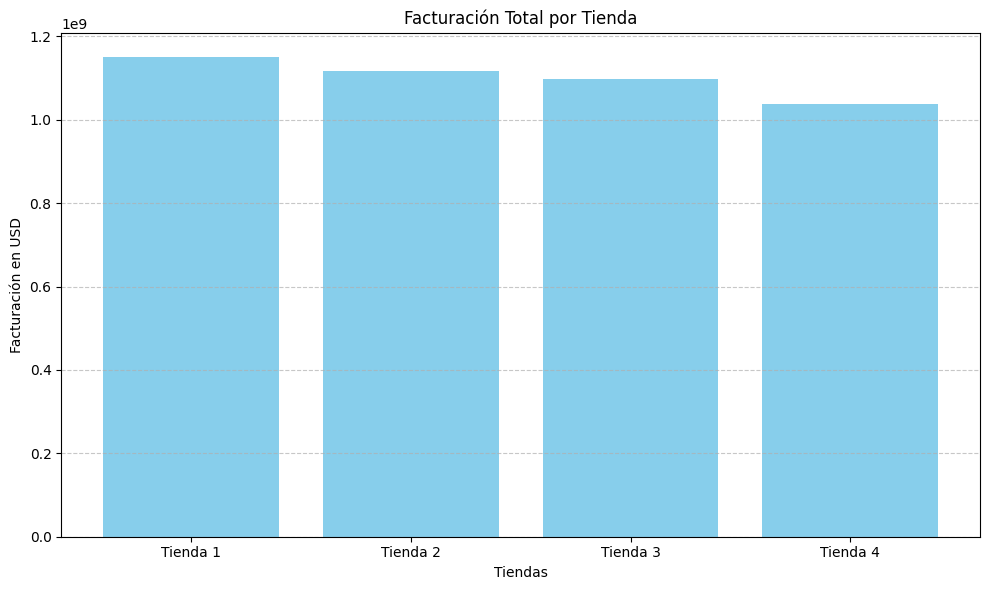

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(nombres_tiendas, facturacion_total, color='skyblue')
plt.title('Facturación Total por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Facturación en USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


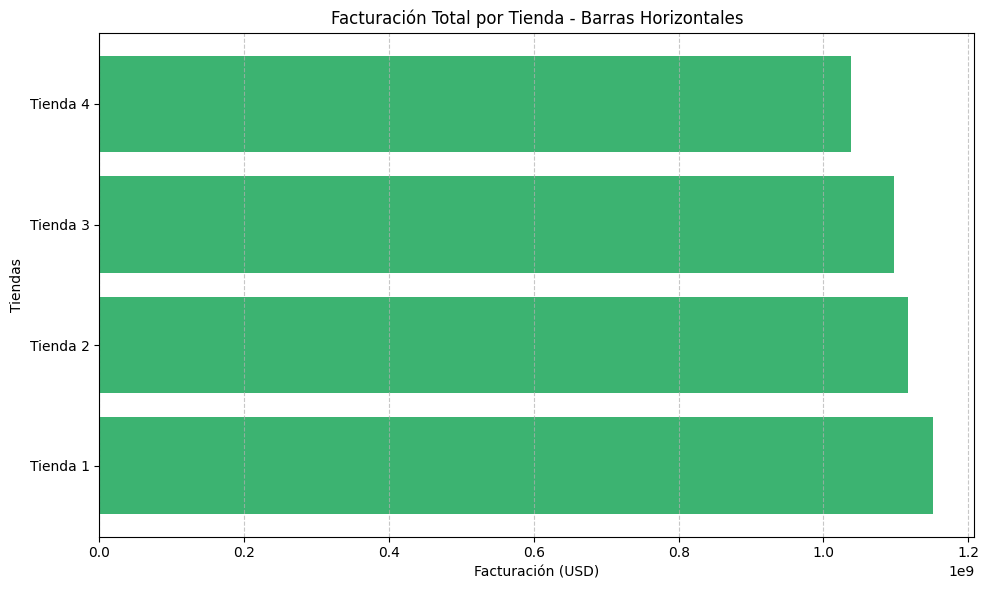

In [12]:
plt.figure(figsize=(10,6))
plt.barh(nombres_tiendas, facturacion_total, color='mediumseagreen')
plt.title('Facturación Total por Tienda - Barras Horizontales')
plt.xlabel('Facturación (USD)')
plt.ylabel('Tiendas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


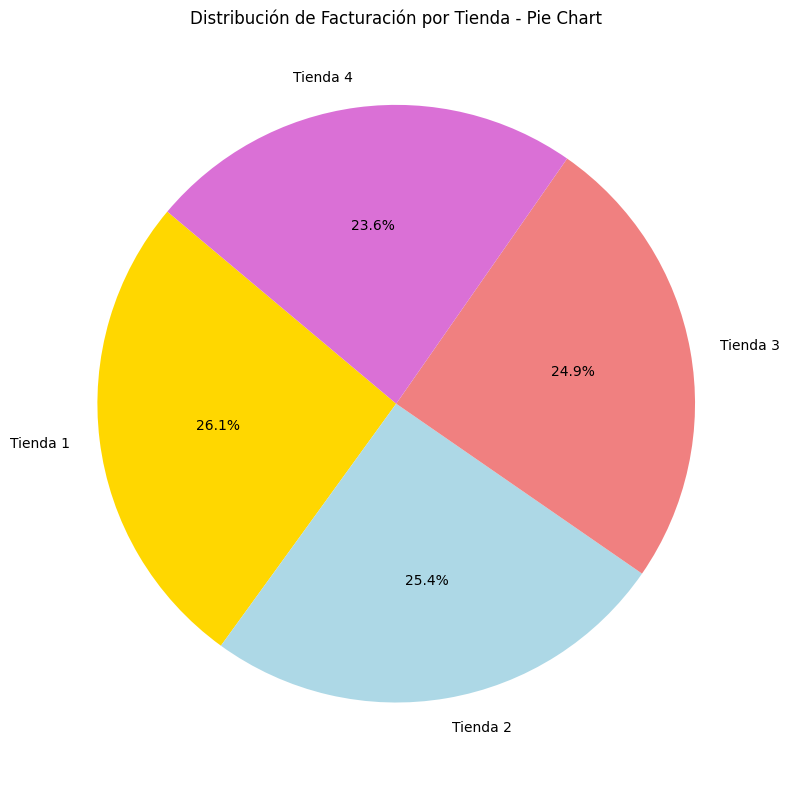

In [14]:
plt.figure(figsize=(8,8))
plt.pie(facturacion_total, labels=nombres_tiendas, autopct='%1.1f%%', startangle=140, colors=['gold', 'lightblue', 'lightcoral', 'orchid'])
plt.title('Distribución de Facturación por Tienda - Pie Chart')
plt.axis('equal')
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [29]:
for i, df in enumerate(tiendas):
    print(f"\nTop categorías más vendidas en {nombres_tiendas[i]}:")
    print(df['Categoría del Producto'].value_counts().head(5))


Top categorías más vendidas en Tienda 1:
Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
Name: count, dtype: int64

Top categorías más vendidas en Tienda 2:
Categoría del Producto
Muebles                 442
Electrónicos            422
Juguetes                313
Electrodomésticos       305
Deportes y diversión    275
Name: count, dtype: int64

Top categorías más vendidas en Tienda 3:
Categoría del Producto
Muebles                 499
Electrónicos            451
Juguetes                315
Electrodomésticos       278
Deportes y diversión    277
Name: count, dtype: int64

Top categorías más vendidas en Tienda 4:
Categoría del Producto
Muebles                 480
Electrónicos            451
Juguetes                338
Deportes y diversión    277
Electrodomésticos       254
Name: count, dtype: int64


In [18]:
for i, df in enumerate(tiendas):
    top_categorias = df['Categoría del Producto'].value_counts().head(5)

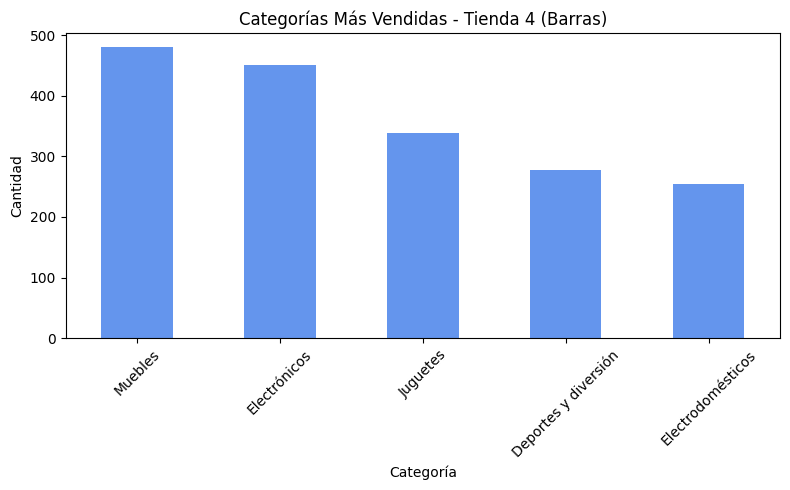

In [19]:
    plt.figure(figsize=(8,5))
    top_categorias.plot(kind='bar', color='cornflowerblue')
    plt.title(f'Categorías Más Vendidas - {nombres_tiendas[i]} (Barras)')
    plt.xlabel('Categoría')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

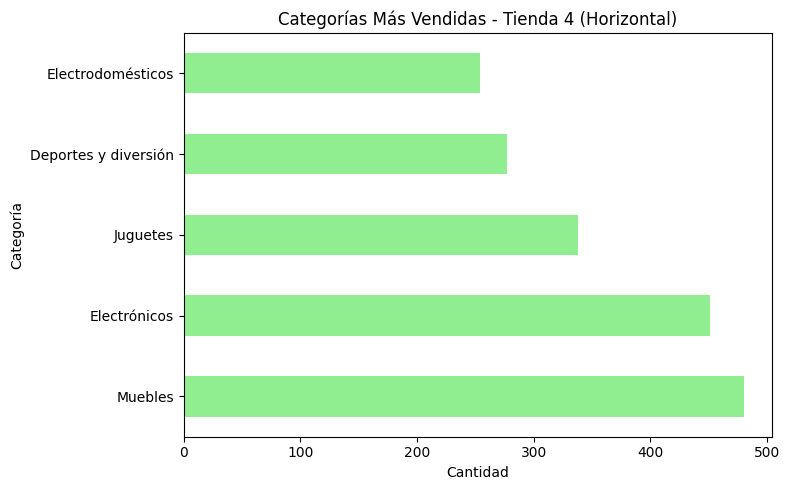

In [23]:
    plt.figure(figsize=(8,5))
    top_categorias.plot(kind='barh', color='lightgreen')
    plt.title(f'Categorías Más Vendidas - {nombres_tiendas[i]} (Horizontal)')
    plt.xlabel('Cantidad')
    plt.ylabel('Categoría')
    plt.tight_layout()
    plt.show()

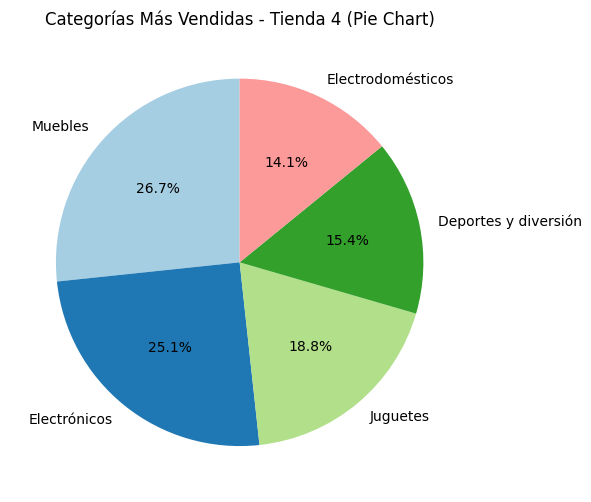

In [22]:
    plt.figure(figsize=(6,6))
    top_categorias.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Categorías Más Vendidas - {nombres_tiendas[i]} (Pie Chart)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# 3. Calificación promedio de la tienda


In [33]:
promedios_calificacion = [df['Calificación'].mean() for df in tiendas]

for nombre, promedio in zip(nombres_tiendas, promedios_calificacion):
  print(f'{nombre} - Calificación promedio: {promedio:.2f}')

Tienda 1 - Calificación promedio: 3.98
Tienda 2 - Calificación promedio: 4.04
Tienda 3 - Calificación promedio: 4.05
Tienda 4 - Calificación promedio: 4.00


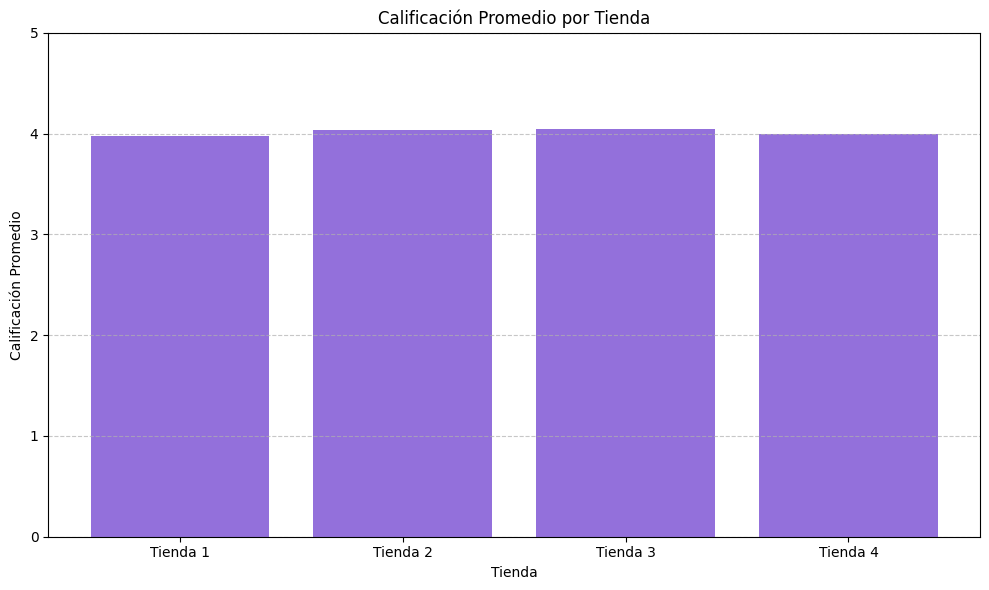

In [34]:
plt.figure(figsize=(10,6))
plt.bar(nombres_tiendas, promedios_calificacion, color='mediumpurple')
plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

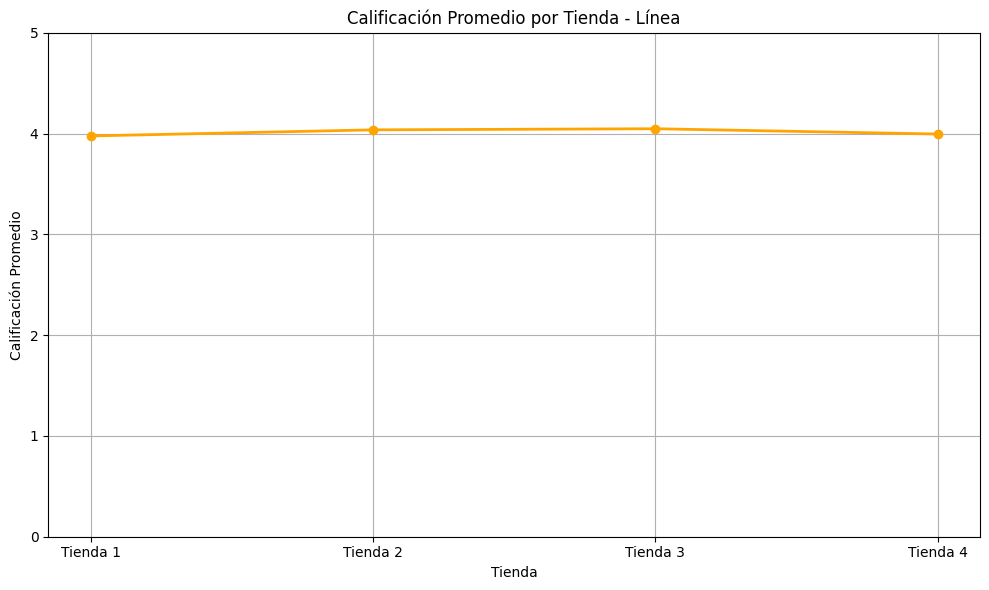

In [38]:
plt.figure(figsize=(10,6))
plt.plot(nombres_tiendas, promedios_calificacion, marker='o', color='orange', linewidth=2)
plt.title('Calificación Promedio por Tienda - Línea')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

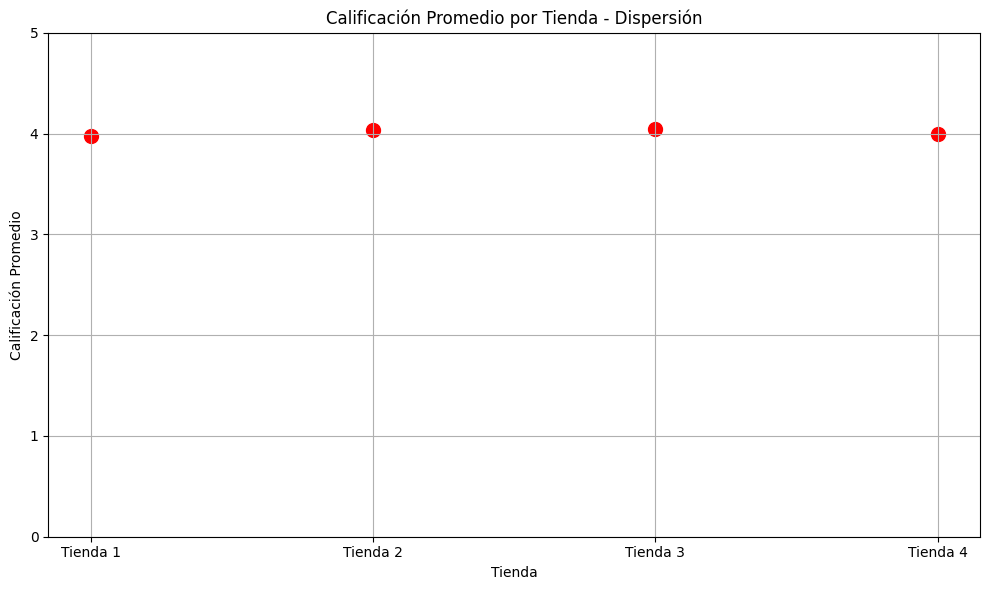

In [36]:
plt.figure(figsize=(10,6))
plt.scatter(nombres_tiendas, promedios_calificacion, color='red', s=100)
plt.title('Calificación Promedio por Tienda - Dispersión')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [42]:
for i, df in enumerate(tiendas):
  print(f'\nMas vendidos en {nombres_tiendas[i]}: ')
  print(df['Producto'].value_counts().head(5))

  print(f'\nMenos vendidos en {nombres_tiendas[i]}: ')
  menos_vendidos = df['Producto'].value_counts().sort_values()
  print(menos_vendidos[menos_vendidos > 1].head(5))


Mas vendidos en Tienda 1: 
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56
Name: count, dtype: int64

Menos vendidos en Tienda 1: 
Producto
Auriculares con micrófono    33
Celular ABXY                 33
Olla de presión              35
Pandereta                    36
Mochila                      39
Name: count, dtype: int64

Mas vendidos en Tienda 2: 
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: count, dtype: int64

Menos vendidos en Tienda 2: 
Producto
Juego de mesa      32
Mesa de comedor    34
Impresora          34
Sillón             35
Auriculares        37
Name: count, dtype: int64

Mas vendidos en Tienda 3: 
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55
Name: count, dtype: int64

Menos vendidos en Tienda 

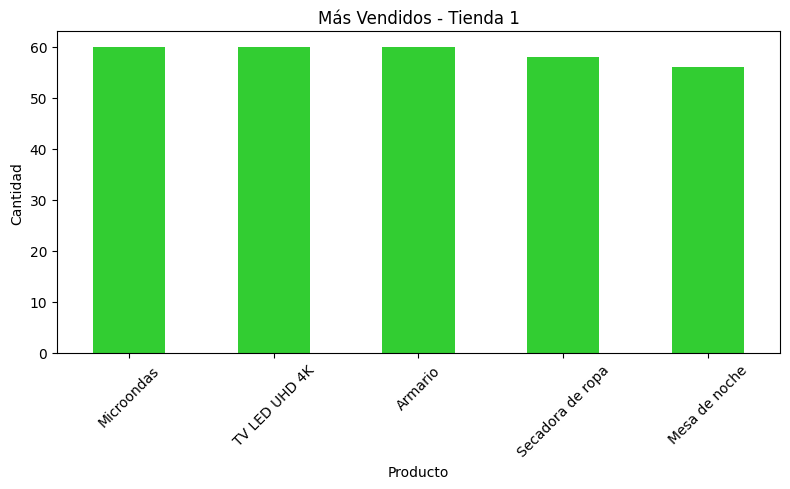

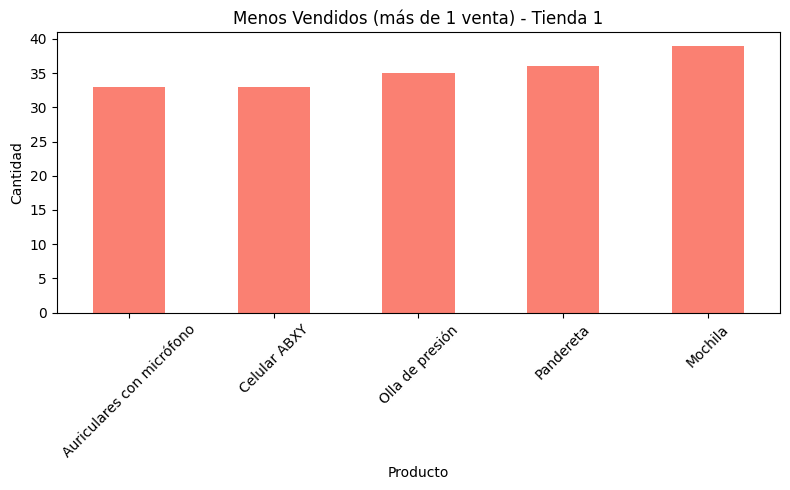

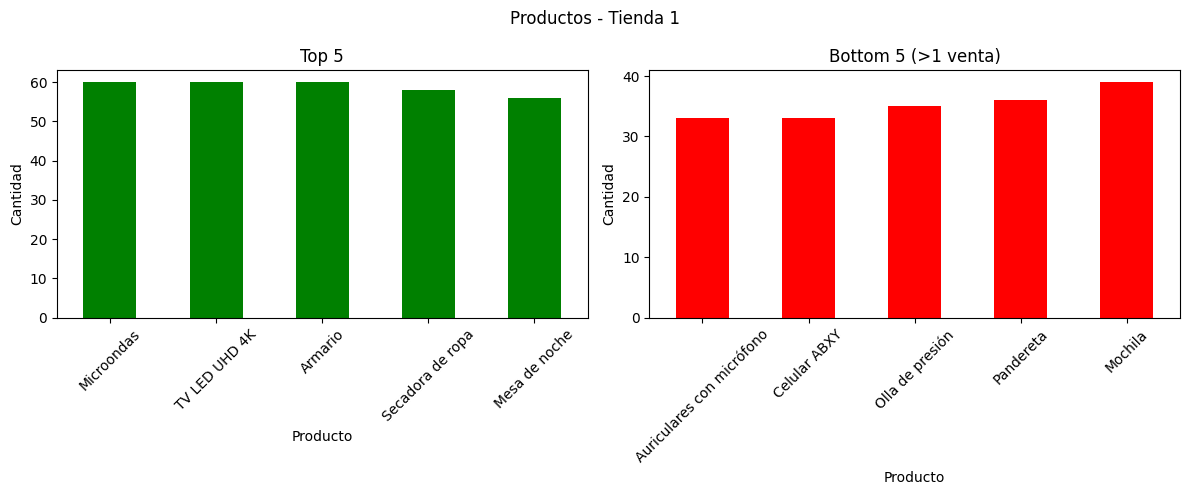

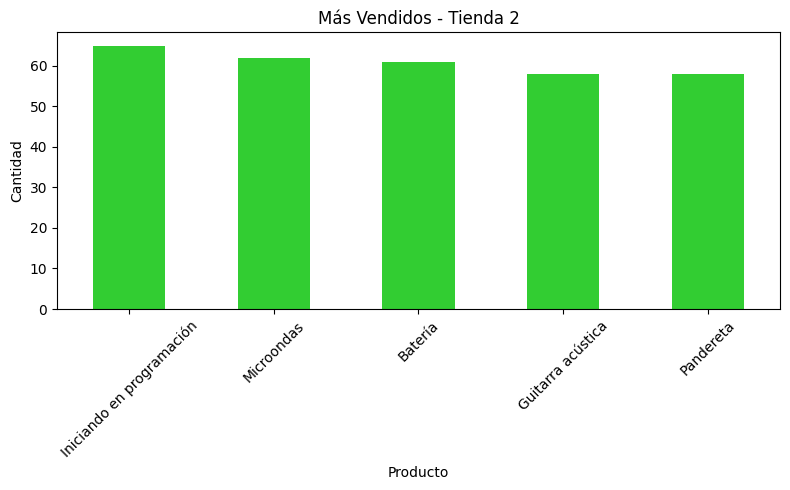

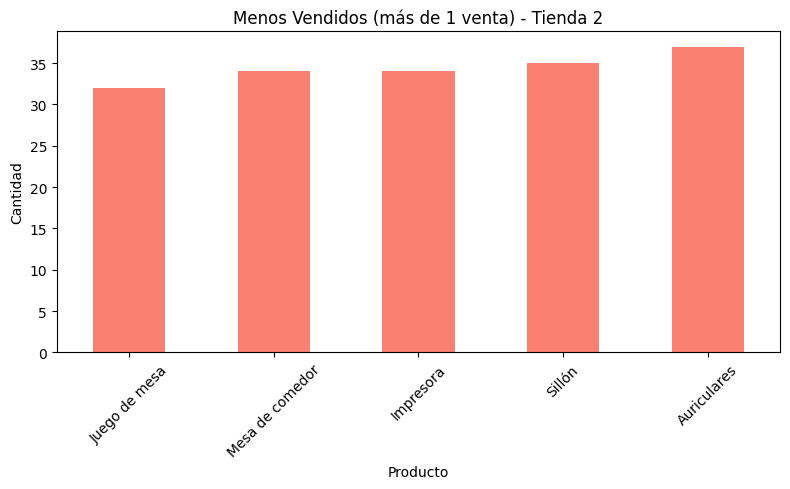

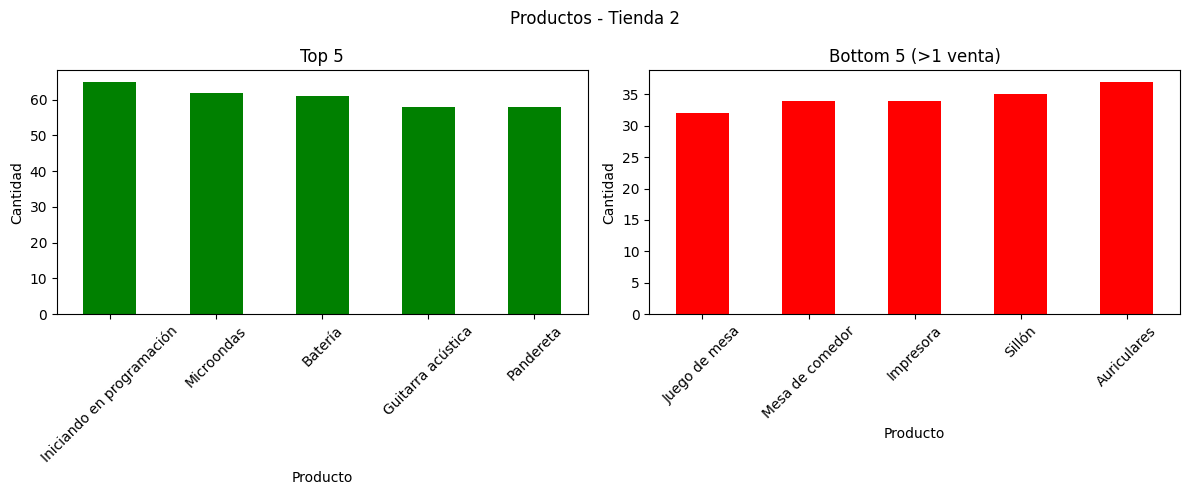

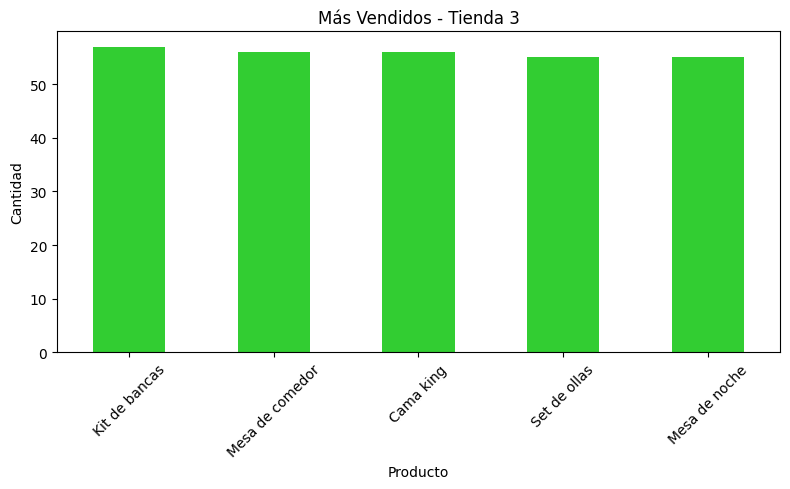

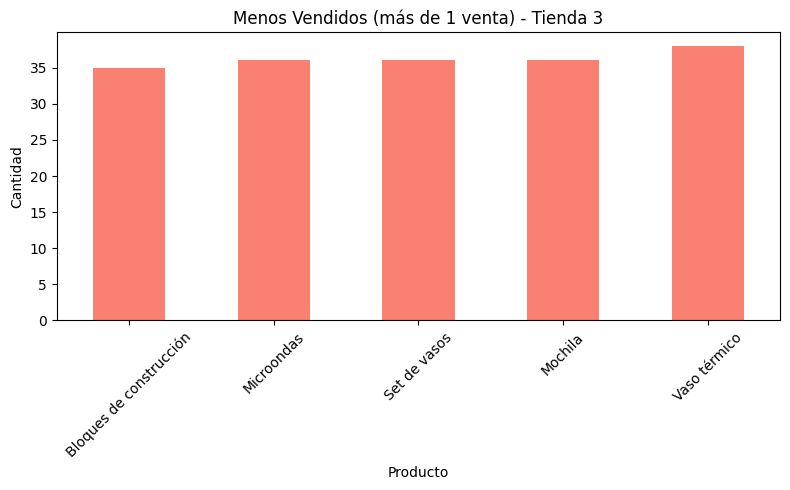

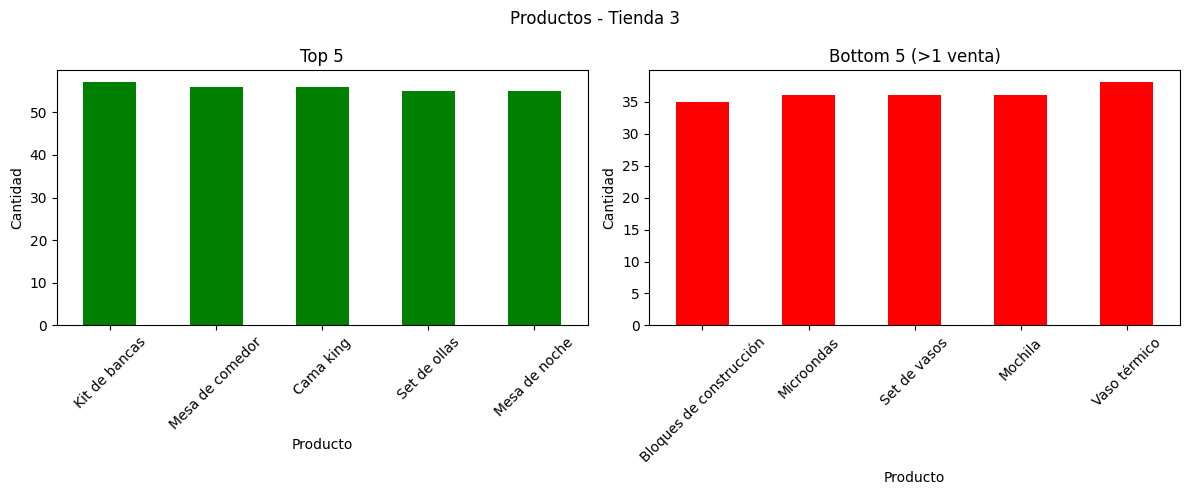

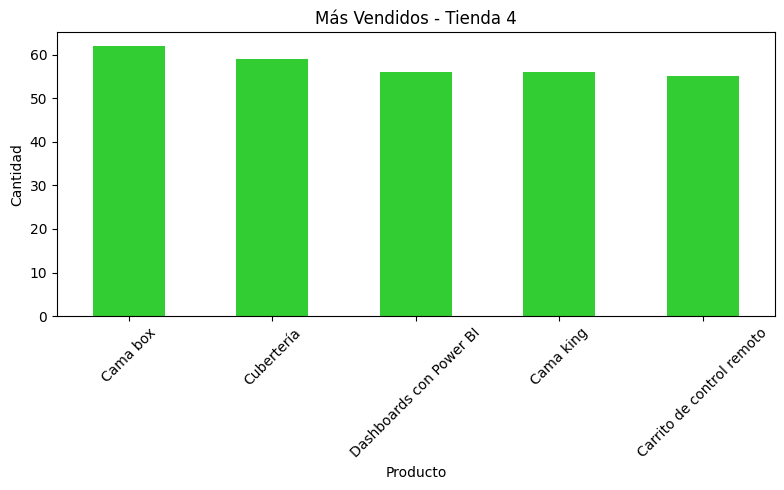

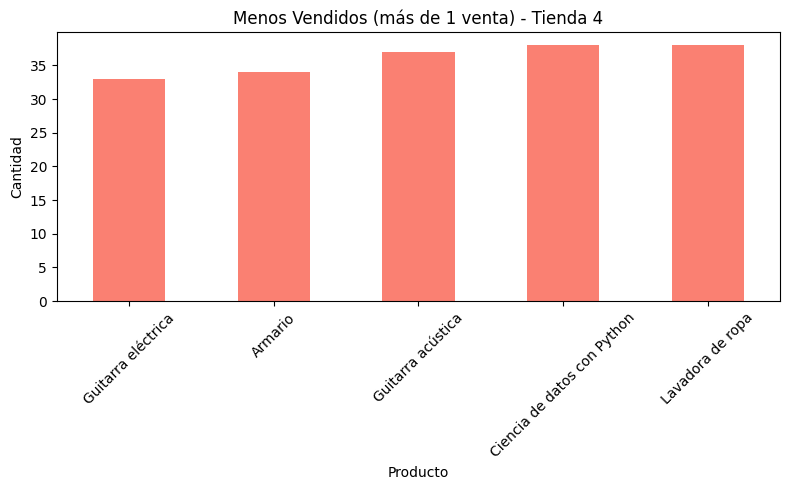

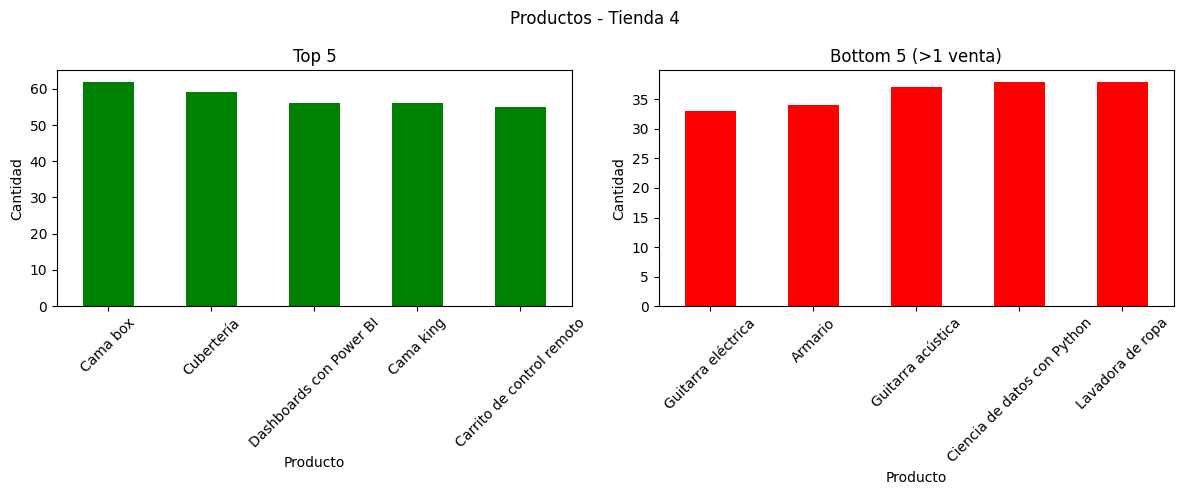

In [51]:
for i, df in enumerate(tiendas):
  top = df['Producto'].value_counts().head(5)
  low = df['Producto'].value_counts().sort_values()
  bottom = low[low > 1].head(5)

  plt.figure(figsize=(8,5))
  top.plot(kind='bar', color='limegreen')
  plt.title(f'Más Vendidos - {nombres_tiendas[i]}')
  plt.xlabel('Producto')
  plt.ylabel('Cantidad')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(8,5))
  bottom.plot(kind='bar', color='salmon')
  plt.title(f'Menos Vendidos (más de 1 venta) - {nombres_tiendas[i]}')
  plt.xlabel('Producto')
  plt.ylabel('Cantidad')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  fig, ax = plt.subplots(1, 2, figsize=(12,5))
  top.plot(kind='bar', ax=ax[0], color='green', title='Top 5')
  bottom.plot(kind='bar', ax=ax[1], color='red', title='Bottom 5 (>1 venta)')
  ax[0].set_ylabel('Cantidad'); ax[1].set_ylabel('Cantidad')
  ax[0].tick_params(axis='x', rotation=45)
  ax[1].tick_params(axis='x', rotation=45)
  plt.suptitle(f'Productos - {nombres_tiendas[i]}')
  plt.tight_layout()
  plt.show()

# 5. Envío promedio por tienda

In [53]:
promedios_envio = [df['Costo de envío'].mean() for df in tiendas]

for nombre, promedio in zip(nombres_tiendas, promedios_envio):
  print(f'{nombre} - Envío promedio: {promedio:.2f}')

Tienda 1 - Envío promedio: 26018.61
Tienda 2 - Envío promedio: 25216.24
Tienda 3 - Envío promedio: 24805.68
Tienda 4 - Envío promedio: 23459.46


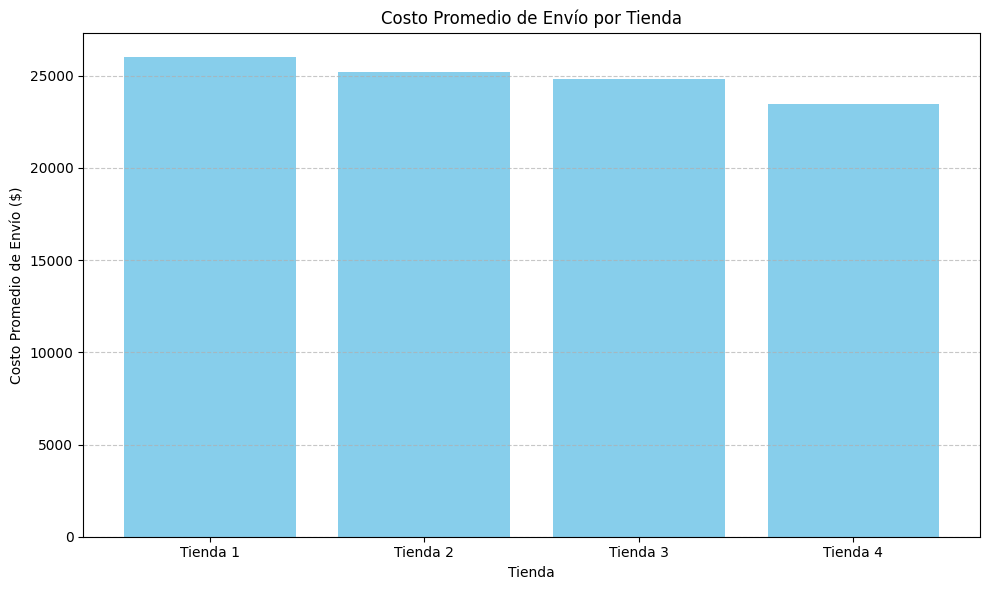

In [54]:
plt.figure(figsize=(10,6))
plt.bar(nombres_tiendas, promedios_envio, color='skyblue')
plt.title('Costo Promedio de Envío por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo Promedio de Envío ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

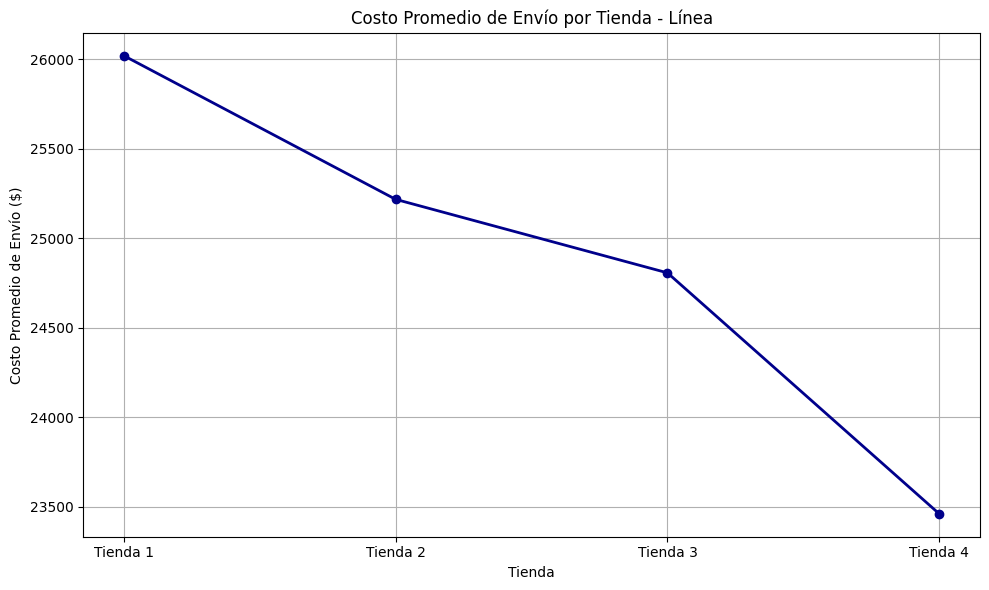

In [55]:
plt.figure(figsize=(10,6))
plt.plot(nombres_tiendas, promedios_envio, marker='o', color='darkblue', linewidth=2)
plt.title('Costo Promedio de Envío por Tienda - Línea')
plt.xlabel('Tienda')
plt.ylabel('Costo Promedio de Envío ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

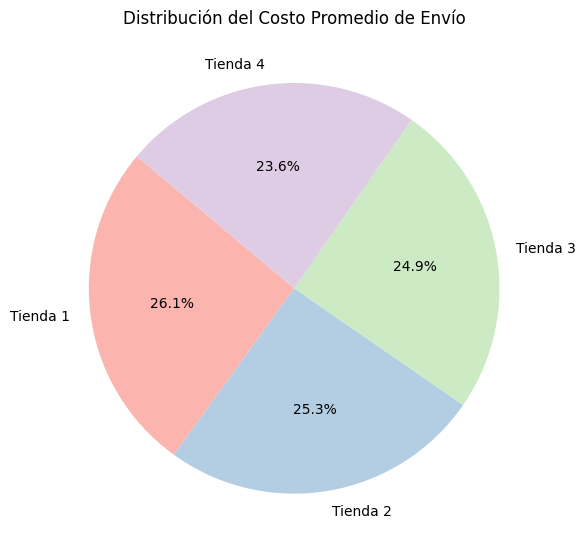

In [56]:
plt.figure(figsize=(6,6))
plt.pie(promedios_envio, labels=nombres_tiendas, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Distribución del Costo Promedio de Envío')
plt.tight_layout()
plt.show()

# 6. ¡EXTRA!
Utilice los datos de latitud (lat) y longitud (lon) para mapear las ventas de cada tienda y analizar la distribución geográfica de los productos vendidos.

Genere gráficos de dispersión o mapas de calor (Heatmaps) para visualizar datos e identificar áreas con la mayor concentración de ventas.

Explore si algunas tiendas tienen un rendimiento superior o inferior al esperado en determinadas regiones e identifique si existen patrones geográficos que puedan influir en el rendimiento de las tiendas.

In [59]:
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

df_total = pd.concat([tienda, tienda2, tienda3, tienda4])

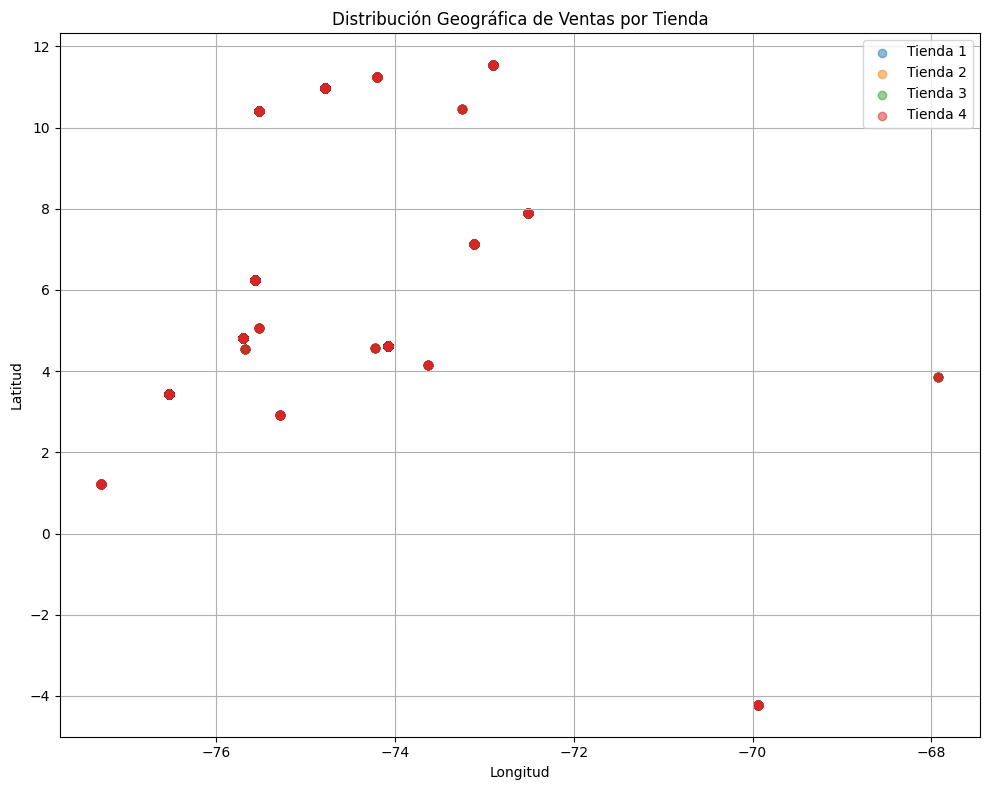

In [60]:
plt.figure(figsize=(10, 8))
for tienda in df_total['Tienda'].unique():
    datos = df_total[df_total['Tienda'] == tienda]
    plt.scatter(datos['lon'], datos['lat'], label=tienda, alpha=0.5)

plt.title('Distribución Geográfica de Ventas por Tienda')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

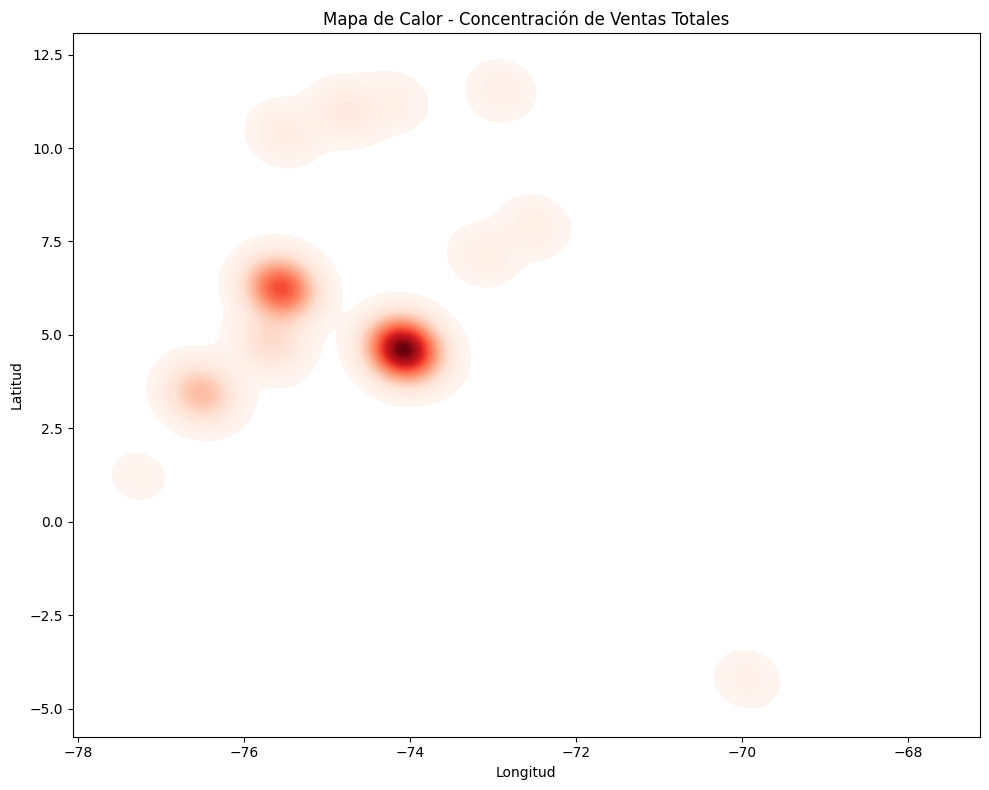

In [61]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.kdeplot(
    data=df_total, x="lon", y="lat", fill=True, cmap="Reds", thresh=0.05, levels=100
)
plt.title("Mapa de Calor - Concentración de Ventas Totales")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()

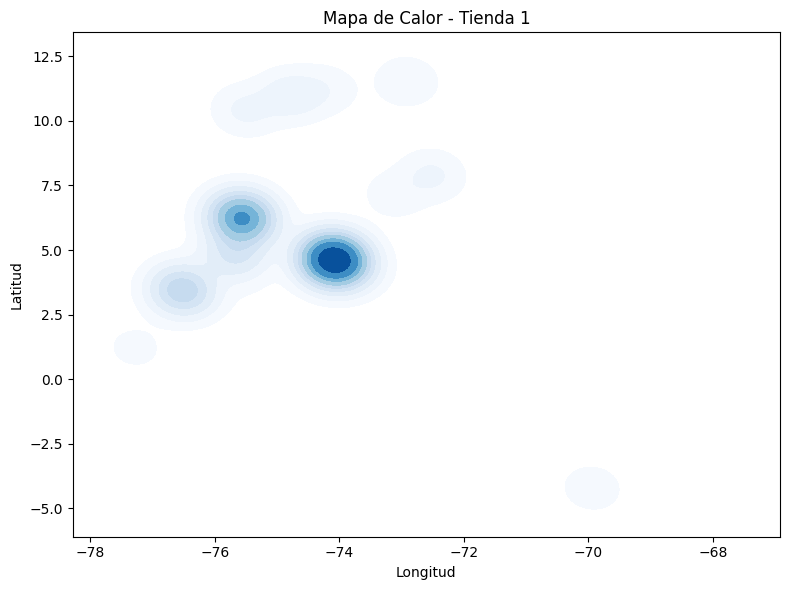

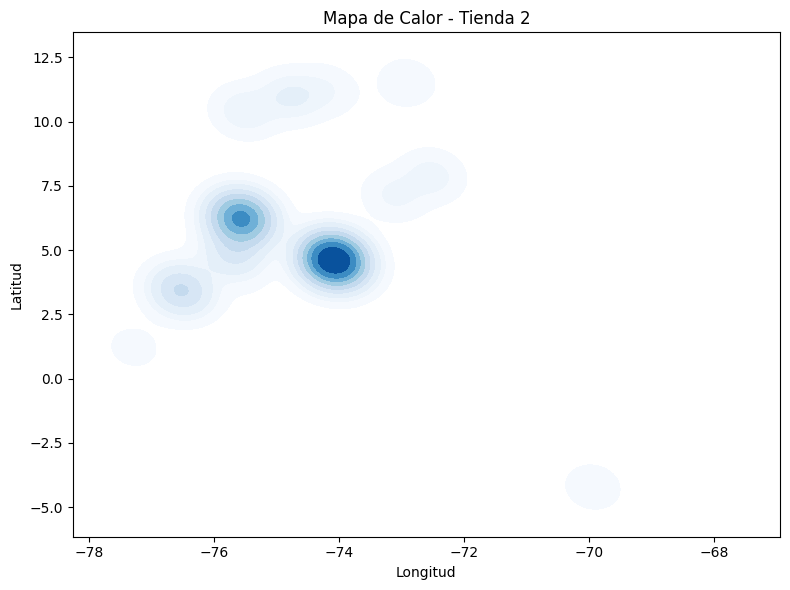

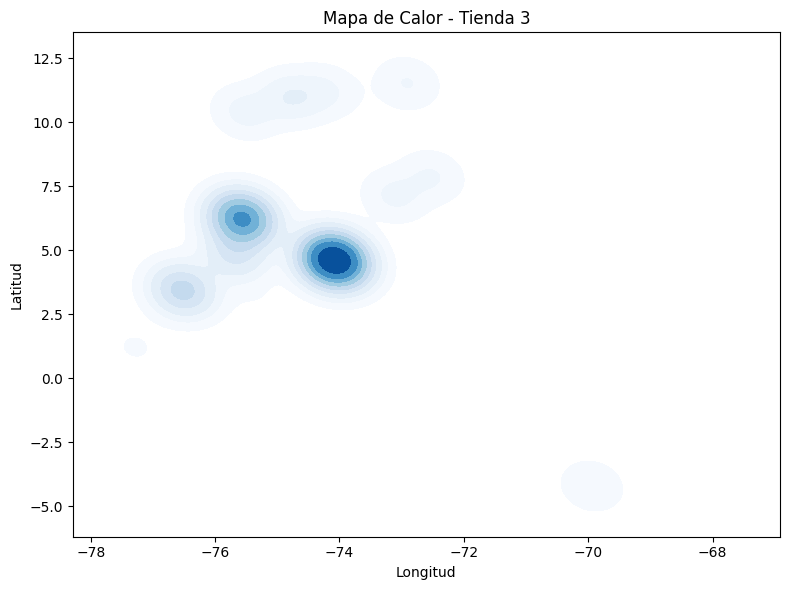

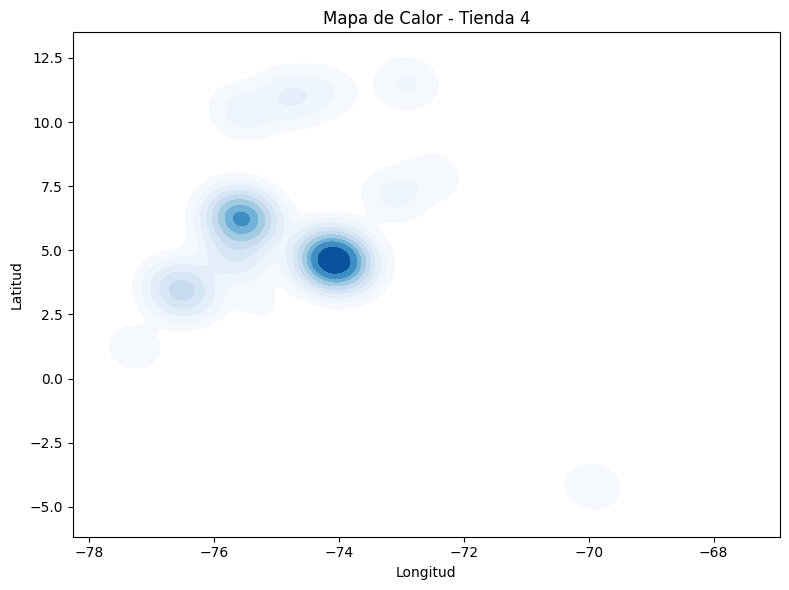

In [62]:
for tienda in df_total['Tienda'].unique():
    datos = df_total[df_total['Tienda'] == tienda]
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=datos, x="lon", y="lat", fill=True, cmap="Blues", thresh=0.05)
    plt.title(f"Mapa de Calor - {tienda}")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.tight_layout()
    plt.show()


# **Informe Final: Análisis de Tiendas para el Sr. Juan**


## Introducción
El propósito de este análisis es ayudar al Sr. Juan a tomar una decisión informada sobre cuál tienda debería vender, basándose en diversos factores clave que afectan el rendimiento de cada tienda. El análisis considera facturación total, categorías más populares, calificaciones promedio de los clientes, productos más y menos vendidos, costo de envío promedio y la distribución geográfica de las ventas.

El objetivo es recomendar la tienda que presente un rendimiento más fuerte en general, considerando los diferentes aspectos de su operación y posicionamiento en el mercado.

## Análisis y Resultados
### 1. Facturación Total de Cada Tienda
La facturación total es una métrica clave para evaluar el rendimiento de una tienda. Los resultados muestran que la Tienda 1 tiene la mayor facturación, con un total de `$1,150,880,400.00`, seguida por la Tienda 2 con `$1,116,343,500.00`. La Tienda 3 y la Tienda 4 tienen una facturación inferior, de `$1,098,019,600.00 ` Código en línea y `$1,038,375,700.00`, respectivamente.

Tienda 1: Facturación más alta.

Tienda 2: Facturación considerablemente alta, solo un poco por debajo de Tienda 1.

Tienda 3 y Tienda 4: Facturación más baja, pero aún relevante.




## 2. Categorías Más y Menos Vendidas
El análisis de las categorías más populares muestra que, en general, las tiendas tienen un buen rendimiento en Muebles, Electrónicos y Juguetes, pero con algunas variaciones. Por ejemplo, la Tienda 1 y Tienda 2 tienen categorías similares, mientras que la Tienda 3 destaca ligeramente con más ventas en la categoría de Muebles.

* Tienda 1 y Tienda 2: Principales categorías: Muebles,

* Electrónicos, Juguetes.

* Tienda 3: Buen desempeño en Muebles y Electrónicos.

* Tienda 4: Similar a las otras tiendas, pero con algo menos de venta en Electrodomésticos.




## 3. Calificación Promedio de los Clientes
Las calificaciones promedio revelan que la Tienda 3 tiene la mejor calificación con 4.05/5, lo que sugiere un excelente nivel de satisfacción de los clientes. Le siguen de cerca la Tienda 2 con 4.04 y la Tienda 4 con 4.00, mientras que la Tienda 1 tiene una calificación ligeramente más baja de 3.98, lo que podría indicar algunas áreas de mejora en cuanto a la satisfacción del cliente.

* Tienda 3: Calificación promedio más alta (4.05).

* Tienda 2: Excelente calificación (4.04).

* Tienda 4: Buena calificación (4.00).

* Tienda 1: Calificación más baja (3.98).

## 4. Productos Más y Menos Vendidos
El análisis de los productos más y menos vendidos revela patrones interesantes. En Tienda 1, los productos más vendidos son Microondas, TV LED UHD 4K y Armarios, mientras que los menos vendidos incluyen Auriculares con micrófono y Celular ABXY. En Tienda 2, productos como Iniciando en programación y Microondas se destacan, mientras que en Tienda 3, Kit de bancas y Mesa de comedor son los más vendidos. Tienda 4 tiene Cama box como su producto más vendido.

* Tienda 1: Microondas y TV LED UHD 4K son productos estrella, mientras que los auriculares tienen una baja venta.

* Tienda 2: Gran rendimiento de productos como Iniciando en programación y Microondas.

* Tienda 3: Buena venta de Kit de bancas y Mesa de comedor.

* Tienda 4: Cama box es el producto más vendido.




## 5. Costo Promedio de Envío
El análisis del costo promedio de envío muestra que Tienda 1 tiene el costo de envío más alto, con `$26,018.61`, mientras que la Tienda 2 tiene un costo ligeramente inferior de `$25,216.24`. Tienda 3 y Tienda 4 también tienen costos de envío más bajos, lo que puede hacer que estas tiendas sean más competitivas en términos de costos adicionales para los clientes.

* Tienda 1: Costo más alto de envío.

* Tienda 2: Costo moderado de envío.

* Tienda 3 y Tienda 4: Costos más bajos.

## 6. Distribución Geográfica de Ventas
Finalmente, el análisis geográfico de las ventas mostró que Tienda 2 tiene la mayor concentración de ventas en varias regiones, lo que sugiere una excelente distribución de sus productos. Tienda 1 tiene una buena distribución, pero en general, las Tiendas 3 y 4 presentan una distribución más limitada, lo que podría afectar su alcance de mercado.

## Conclusión
Basado en los análisis realizados, la Tienda 2 es la opción más recomendada para que el Sr. Juan invierta. Aunque Tienda 1 tiene una mayor facturación, la Tienda 2 presenta un rendimiento más equilibrado, destacando en términos de calificación de clientes, categorías populares, y un costo de envío moderado.

La Tienda 3 tiene la mejor calificación de clientes, pero su facturación es inferior. Además, la Tienda 4, aunque tiene buenos productos, no ofrece una ventaja significativa en comparación con las otras.

Por lo tanto, la Tienda 2 es la mejor opción, no solo por su facturación, sino también por su diversidad de productos y buen desempeño general.

